In [ ]:
import matplotlib.pyplot as plt
import importlib

import msm_system_construction
import msm_systems
import unbiased_simulation_analysis

implied timescale converged to within 5.0% of the value calculated for 200 bins at 45 bins


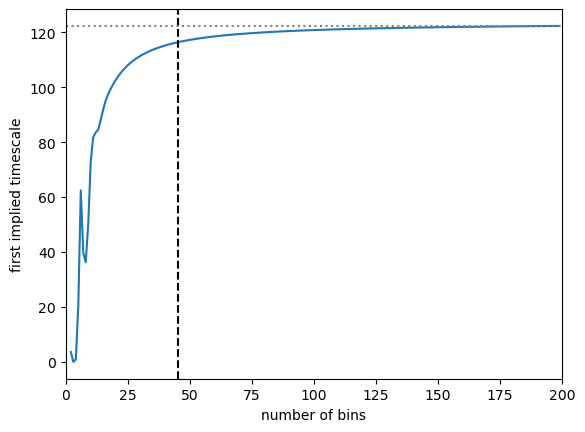

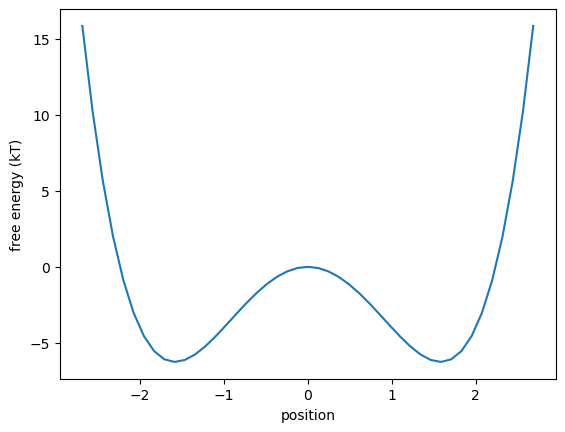

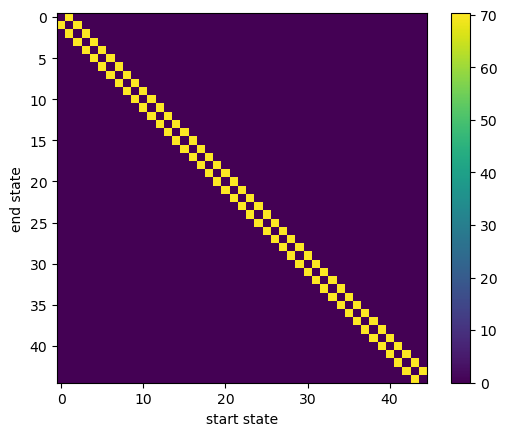

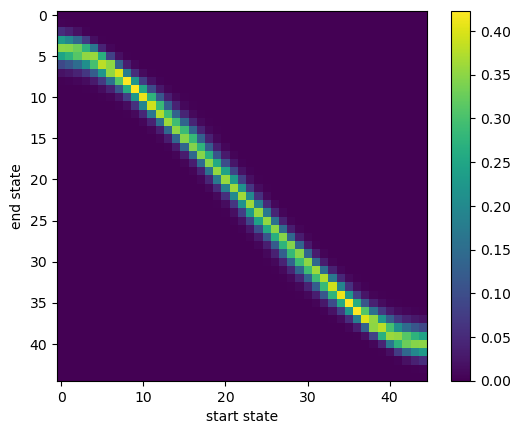

In [4]:
importlib.reload(msm_systems)
importlib.reload(msm_system_construction)

A = 1
B = 5
D = 1
dw1 = msm_systems.double_well(A, B, D)

kT = 1
lag_time = 0.01

min_bins = msm_system_construction.timescale_vs_spatial_discretization(dw1, kT, lag_time, (2,200), tolerance=0.05)

g_eq, prefactors, xb = msm_system_construction.spatially_discretize_linear_system(dw1, min_bins)

plt.plot(xb, g_eq)
plt.xlabel("position")
plt.ylabel("free energy (kT)")
plt.show()

plt.imshow(prefactors)
plt.colorbar()
plt.xlabel("start state")
plt.ylabel("end state")
plt.show()

tpm = msm_system_construction.energies_and_prefactors_to_tpm(g_eq, prefactors, kT, lag_time)
plt.imshow(tpm)
plt.colorbar()
plt.xlabel("start state")
plt.ylabel("end state")
plt.show()

In [8]:
importlib.reload(unbiased_simulation_analysis)

unbiased_simulation_analysis.unbiased_simulation_to_mtd_params(tpm, min_bins, init_state=np.argmin(g_eq), lag_time=lag_time, n_steps=-1)

implied_timescale: 11634.959306272818 (lag_times)
running for 116 steps
Estimated discrete time rate prefactor between adjacent states: 0.2711058857232688 per frame save interval
Estimated whole-system diffusive timescale: 1867.3515650514294 frame save intervals
Estimated barrier from MFPT and diffusion in initial state:  1.829493147594077  kT


(2.024871364508418, 0.1, 15.12362607645989, 2.658986295188154)